In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import DataLoader,Dataset
import torch.optim as optim
import torch.nn as nn
import matplotlib.pyplot as plt

In [23]:
torch.manual_seed(42)

In [24]:
#check for GPU
print(torch.__version__)
print(torch.__file__)
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
import sys
print(sys.executable)

2.6.0+cu124
c:\Users\ritam\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\__init__.py
cuda
c:\Users\ritam\AppData\Local\Programs\Python\Python313\python.exe


In [25]:
df=pd.read_csv('fashion-mnist_train.csv')
df.head()


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


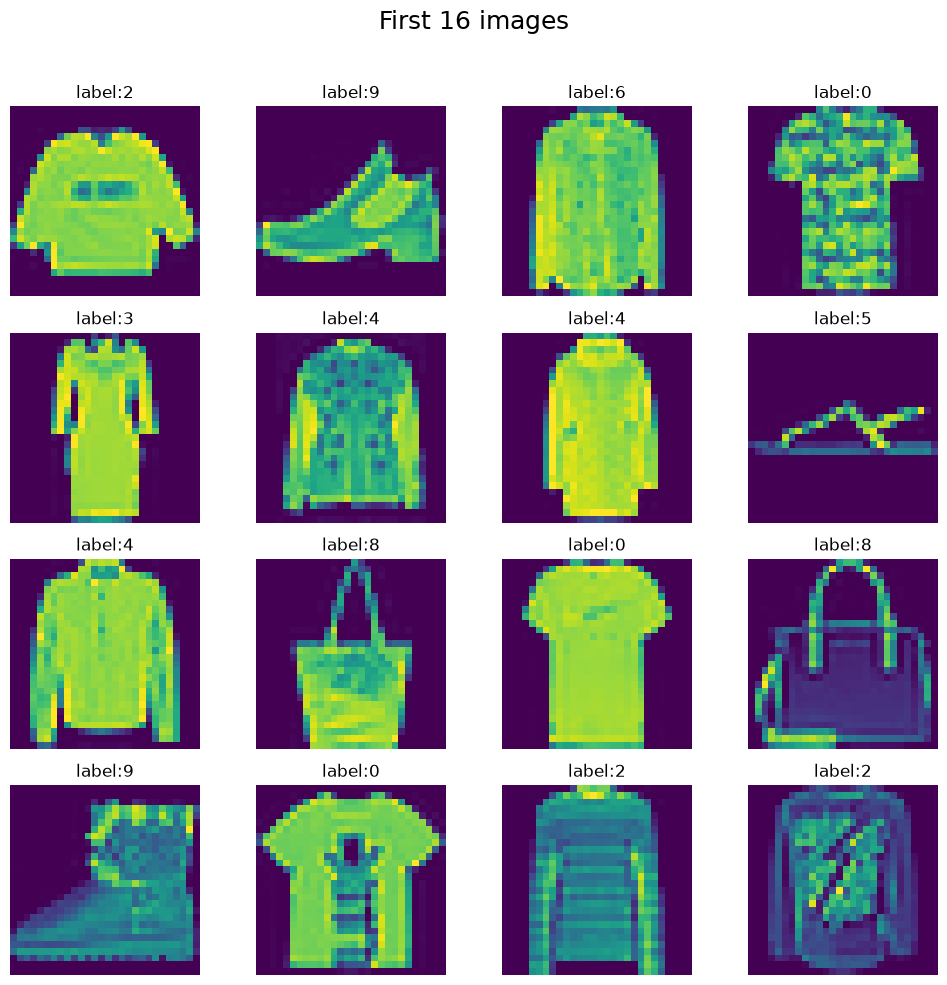

In [26]:
#create 4x4 grid images
fig,axes=plt.subplots(4,4,figsize=(10,10))
fig.suptitle("First 16 images",fontsize=18)
#now plot the 16 images from the dataset
for i,ax in enumerate(axes.flat):
    img=df.iloc[i,1:].values.reshape(28,28)
    ax.imshow(img)  #display in grayscale
    ax.axis('off') #this is just removing the axes
    ax.set_title(f"label:{df.iloc[i,0]}")
plt.tight_layout(rect=[0,0,1,0.96])  #adjust layout to fit the title
plt.show()


In [27]:
#train_test_split
X=df.iloc[:,1:].values
y=df.iloc[:,0].values


In [28]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [29]:
#scaling the features
X_train=X_train/255.0
X_test=X_test/255.0

In [30]:
#create CustomDataset class
class CustomDataset(Dataset):
  def __init__(self,X,y):
    self.features=torch.tensor(X,dtype=torch.float32)
    self.labels=torch.tensor(y,dtype=torch.long)
  def __len__(self):
    return len(self.features)
  def __getitem__(self,idx):
    return self.features[idx],self.labels[idx]

In [31]:
#create train_dataset obj
train_dataset=CustomDataset(X_train,y_train)

In [32]:
#create test_dataset obj
test_dataset=CustomDataset(X_test,y_test)

In [33]:
#create train and test loder
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True,pin_memory=True)
test_loader=DataLoader(test_dataset,batch_size=32,shuffle=False,pin_memory=True) #we dont want to shuffle when predicting

In [34]:
#DEFINE NN class
class My_NN(nn.Module):
  def __init__(self,num_features):
    super().__init__()
    self.model=nn.Sequential(
        nn.Linear(num_features,512),
        nn.BatchNorm1d(512),
        nn.ReLU(),
        nn.Linear(512,128),
        nn.BatchNorm1d(128),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(128,64),
        nn.BatchNorm1d(64),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(64,10)    #we are not doing softmax here, since pytorch has defined softmax internally in cross-entropy loss
    )

  def forward(self,x):
    return self.model(x)

In [35]:
#set learning rate and epochs
learning_rate=0.35
epochs=60

In [36]:
#instantiate the model
model=My_NN(X_train.shape[1])
model.to(device)
loss_fun=nn.CrossEntropyLoss()
optimizer=optim.SGD(model.parameters(),lr=learning_rate,weight_decay=1e-4)

In [37]:
#training loop
for epoch in range(epochs):
  total_epoch_loss=0
  for batch_features,batch_labels in train_loader:
    #move data to gpu
    batch_features,batch_labels=batch_features.to(device),batch_labels.to(device)
    #forward pass
    out=model(batch_features)
    #calcualte loss
    loss=loss_fun(out,batch_labels)

    #backward pass
    optimizer.zero_grad()
    loss.backward()
    #optimizer-update the grads
    optimizer.step()
    total_epoch_loss=total_epoch_loss+loss.item()
  print(f"Avg loss in epoch{epoch+1}:{total_epoch_loss/len(train_dataset)}")

Avg loss in epoch1:0.01916117928146074
Avg loss in epoch2:0.014751293901043634
Avg loss in epoch3:0.013221769907822211
Avg loss in epoch4:0.012507314725934218
Avg loss in epoch5:0.011796420786064118
Avg loss in epoch6:0.011258004161141193
Avg loss in epoch7:0.011029386701217543
Avg loss in epoch8:0.010631213827213893
Avg loss in epoch9:0.010236915364939099
Avg loss in epoch10:0.010070692479998495
Avg loss in epoch11:0.009846142290121256
Avg loss in epoch12:0.0096564840626282
Avg loss in epoch13:0.009574605146422983
Avg loss in epoch14:0.00931420642323792
Avg loss in epoch15:0.00924670409783721
Avg loss in epoch16:0.009092132938172048
Avg loss in epoch17:0.00894385677583826
Avg loss in epoch18:0.00890525971663495
Avg loss in epoch19:0.008812039589509367
Avg loss in epoch20:0.008771306845359504
Avg loss in epoch21:0.008560394300225501
Avg loss in epoch22:0.008574643313263854
Avg loss in epoch23:0.008415930549614132
Avg loss in epoch24:0.008266804191283882
Avg loss in epoch25:0.0082129494

In [38]:
#set model to eval
model.eval()

My_NN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=128, bias=True)
    (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Dropout(p=0.3, inplace=False)
    (7): Linear(in_features=128, out_features=64, bias=True)
    (8): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Dropout(p=0.3, inplace=False)
    (11): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [41]:
#eval code
total=0
correct=0
with torch.no_grad():
  for batch_features,batch_labels in test_loader:
     #move data to gpu
    batch_features,batch_labels=batch_features.to(device),batch_labels.to(device)
    out=model(batch_features)
    _,predicted=torch.max(out,1)
    total=total+batch_labels.shape[0]
    correct=correct+(predicted==batch_labels).sum().item()
print(f"Accuracy:{correct/total}")


Accuracy:0.8684166666666666


In [40]:
print(next(model.parameters()).device)

cuda:0
